# **Project Name**    -
Playstore Review analysis


# **Project Summary -**

Write the summary here within 500-600 words.

# **GitHub Link -**

Provide your GitHub Link here.

https://github.com/ananthgarg19981605-del/Playstore-Review/

# **Problem Statement**


**Write Problem Statement Here.**

#### **Define Your Business Objective?**

Answer Here.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 20 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [8]:
# Import Libraries

### Dataset Loading

In [9]:
# Load Dataset

### Dataset First View

In [10]:
# Dataset First Look

### Dataset Rows & Columns count

In [11]:
# Dataset Rows & Columns count

### Dataset Information

In [12]:
# Dataset Info

#### Duplicate Values

In [13]:
# Dataset Duplicate Value Count

#### Missing Values/Null Values

In [14]:
# Missing Values/Null Values Count

In [15]:
# Visualizing the missing values

### What did you know about your dataset?

Answer Here

## ***2. Understanding Your Variables***

In [16]:
# Dataset Columns

In [17]:
# Dataset Describe

### Variables Description

Answer Here

### Check Unique Values for each variable.

In [18]:
# Check Unique Values for each variable.

## 3. ***Data Wrangling***

### Data Wrangling Code

In [19]:
# Write your code to make your dataset analysis ready.

import pandas as pd
import numpy as np

# 1. Load the datasets
apps_df = pd.read_csv('Play Store Data (1).csv')
reviews_df = pd.read_csv('User Reviews (1).csv')

# --- CLEANING PLAY STORE DATA ---

# A. Handle missing Ratings (filling with median to avoid outlier skew)
apps_df['Rating'] = apps_df['Rating'].fillna(apps_df['Rating'].median())

# B. Convert Reviews to numeric (handling potential invalid strings)
apps_df['Reviews'] = pd.to_numeric(apps_df['Reviews'], errors='coerce')
apps_df.dropna(subset=['Reviews'], inplace=True) # Remove 1-2 corrupted rows if any

# C. Clean Installs (Remove '+' and ',' then convert to int)
apps_df['Installs'] = apps_df['Installs'].str.replace('+', '').str.replace(',', '')
apps_df['Installs'] = pd.to_numeric(apps_df['Installs'], errors='coerce')

# D. Clean Price (Remove '$' and convert to float)
apps_df['Price'] = apps_df['Price'].str.replace('$', '')
apps_df['Price'] = pd.to_numeric(apps_df['Price'], errors='coerce')

# E. Standardize Size (Convert everything to MB)
def clean_size(size):
    if isinstance(size, str):
        if 'M' in size:
            return float(size.replace('M', ''))
        elif 'k' in size:
            return float(size.replace('k', '')) / 1024
        elif 'Varies with device' in size:
            return np.nan
    return size

apps_df['Size'] = apps_df['Size'].apply(clean_size)
# Fill Size NaNs with the median size of their specific Category
apps_df['Size'] = apps_df.groupby('Category')['Size'].transform(lambda x: x.fillna(x.median()))

# F. Remove Duplicates
apps_df.drop_duplicates(subset='App', inplace=True)

# --- CLEANING USER REVIEWS ---

# G. Remove rows with no review text
reviews_df.dropna(subset=['Translated_Review'], inplace=True)

# H. Aggregate Sentiment scores per App
# We take the mean so we have one sentiment score per application
reviews_agg = reviews_df.groupby('App').agg({
    'Sentiment_Polarity': 'mean',
    'Sentiment_Subjectivity': 'mean'
}).reset_index()

# --- FINAL MERGE ---

# I. Merge both datasets into one "Master" DataFrame
merged_df = pd.merge(apps_df, reviews_agg, on='App', how='inner')

# J. Save the results
merged_df.to_csv('cleaned_playstore_data.csv', index=False)

print("Data Wrangling Complete!")
print(f"Final dataset shape: {merged_df.shape}")
merged_df.head()

Data Wrangling Complete!
Final dataset shape: (816, 15)


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Sentiment_Polarity,Sentiment_Subjectivity
0,Coloring book moana,ART_AND_DESIGN,3.9,967.0,14.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,0.152652,0.641540
1,Garden Coloring Book,ART_AND_DESIGN,4.4,13791.0,33.0,1000000,Free,0.0,Everyone,Art & Design,"September 20, 2017",2.9.2,3.0 and up,0.268483,0.523447
2,FlipaClip - Cartoon animation,ART_AND_DESIGN,4.3,194216.0,39.0,5000000,Free,0.0,Everyone,Art & Design,"August 3, 2018",2.2.5,4.0.3 and up,0.412649,0.679226
3,Boys Photo Editor - Six Pack & Men's Suit,ART_AND_DESIGN,4.1,654.0,12.0,100000,Free,0.0,Everyone,Art & Design,"March 20, 2018",1.1,4.0.3 and up,0.283509,0.479298
4,Colorfit - Drawing & Coloring,ART_AND_DESIGN,4.7,20260.0,25.0,500000,Free,0.0,Everyone,Art & Design;Creativity,"October 11, 2017",1.0.8,4.0.3 and up,0.171836,0.572762


### What all manipulations have you done and insights you found?

Answer Here.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

/tmp/ipykernel_1704/7535953.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_categories.index, y=top_categories.values, palette="viridis")


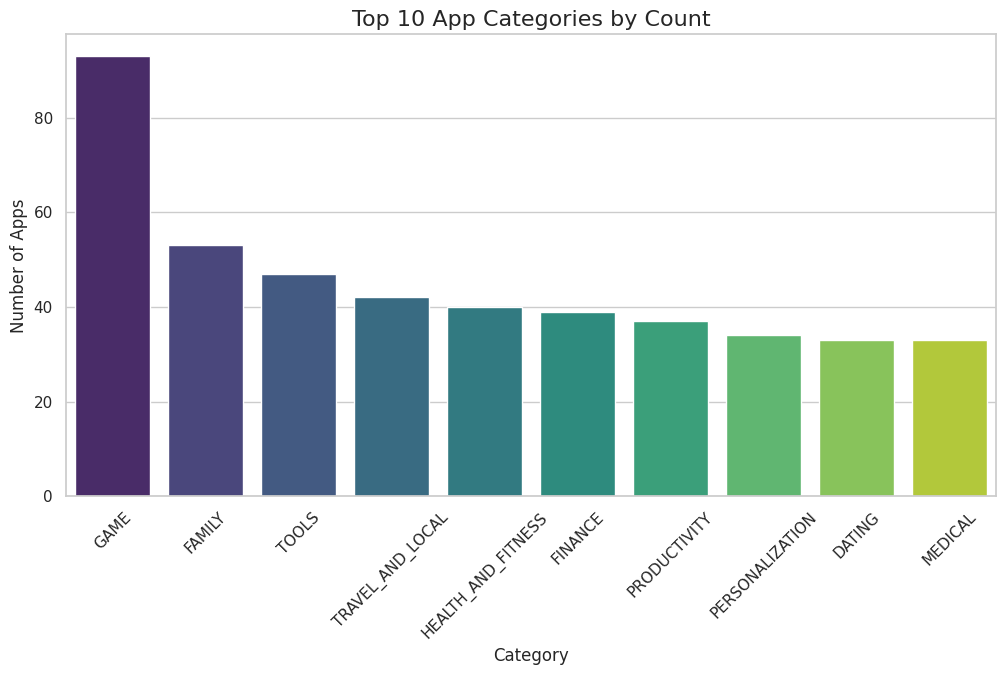

In [20]:
# Chart - 1 visualization code
import matplotlib.pyplot as plt
import seaborn as sns

# Setting the visual style for all plots
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Counting apps per category and taking the top 10
top_categories = merged_df['Category'].value_counts().head(10)

sns.barplot(x=top_categories.index, y=top_categories.values, palette="viridis")
plt.title('Top 10 App Categories by Count', fontsize=16)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Number of Apps', fontsize=12)
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here. This helps stakeholders identify which segments are the most crowded (competitive).

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 2

In [21]:
# Chart - 2 visualization code

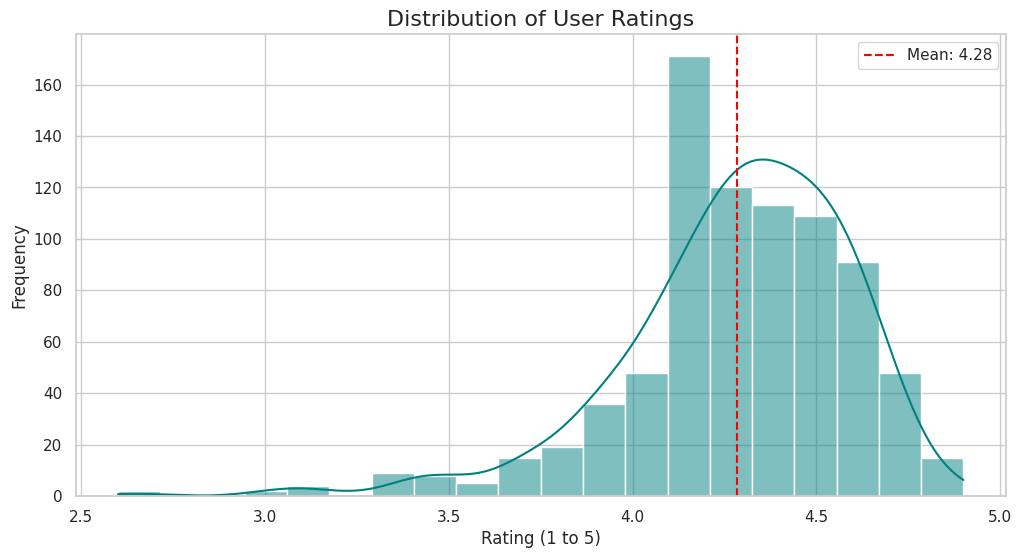

In [22]:
sns.histplot(merged_df['Rating'], bins=20, kde=True, color="teal")
plt.title('Distribution of User Ratings', fontsize=16)
plt.xlabel('Rating (1 to 5)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.axvline(merged_df['Rating'].mean(), color='red', linestyle='--', label=f"Mean: {merged_df['Rating'].mean():.2f}")
plt.legend()
plt.show()

##### 1. Why did you pick the specific chart?
Most apps are rated between 4.0 and 4.7. Very few apps have ratings below 3.0, indicating high user expectations.

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 3

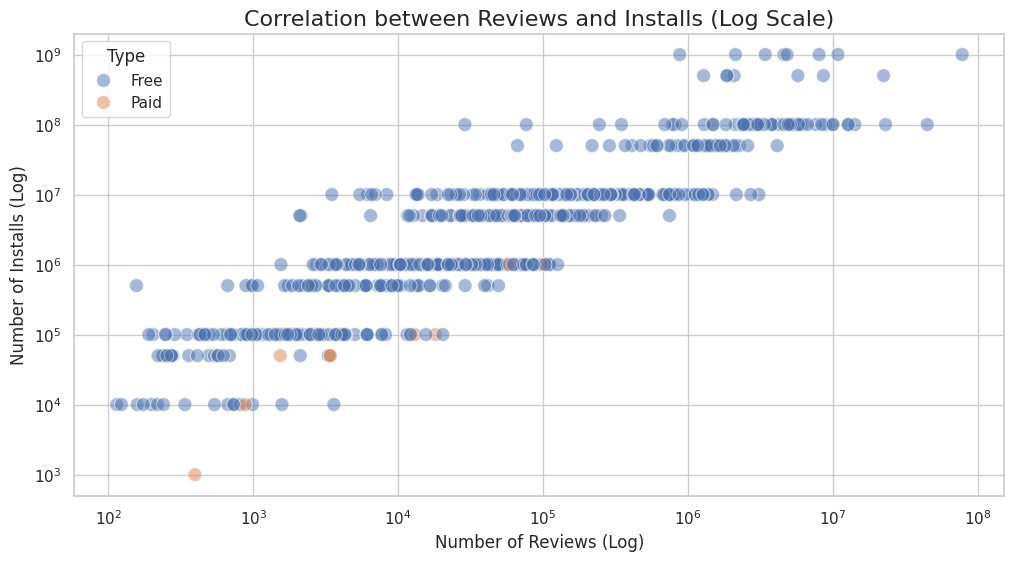

In [23]:
# Chart - 3 visualization code

# Using a Log Scale because the numbers range from thousands to billions
sns.scatterplot(data=merged_df, x='Reviews', y='Installs', hue='Type', alpha=0.5, s=100)
plt.xscale('log')
plt.yscale('log')
plt.title('Correlation between Reviews and Installs (Log Scale)', fontsize=16)
plt.xlabel('Number of Reviews (Log)', fontsize=12)
plt.ylabel('Number of Installs (Log)', fontsize=12)
plt.show()

##### 1. Why did you pick the specific chart?

There is a clear linear trend on the log scale, proving that as an app gets more reviews, it significantly drives more installs.

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 4

/tmp/ipykernel_1704/3572793726.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Type', y='Rating', data=merged_df, palette="Set2")


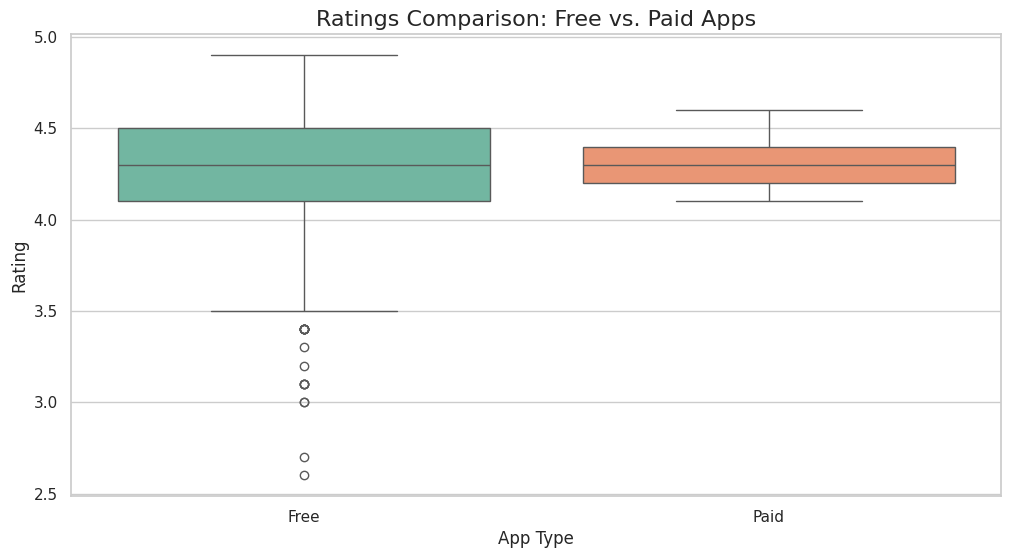

In [24]:
# Chart - 4 visualization code
sns.boxplot(x='Type', y='Rating', data=merged_df, palette="Set2")
plt.title('Ratings Comparison: Free vs. Paid Apps', fontsize=16)
plt.xlabel('App Type', fontsize=12)
plt.ylabel('Rating', fontsize=12)
plt.show()

##### 1. Why did you pick the specific chart?

Paid apps often have a narrower rating spread and a higher median, suggesting that users who pay for apps might be more satisfied or that paid apps are generally more polished.

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 5

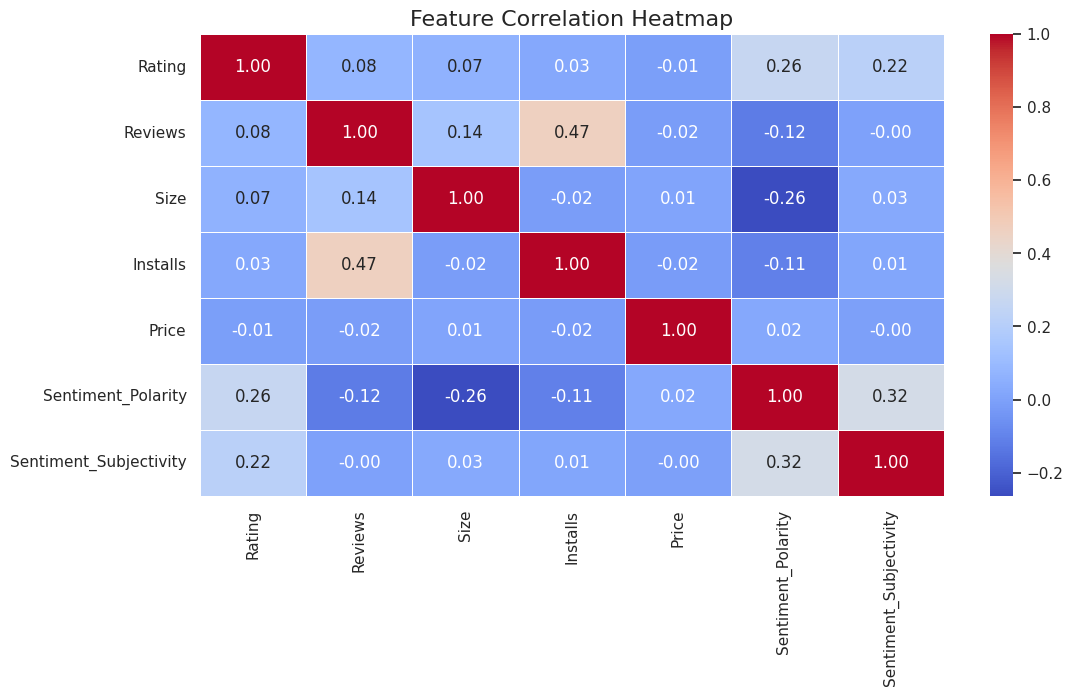

In [25]:
# Chart - 5 visualization code
# Selecting only numerical columns for correlation
corr_data = merged_df[['Rating', 'Reviews', 'Size', 'Installs', 'Price', 'Sentiment_Polarity', 'Sentiment_Subjectivity']]
correlation_matrix = corr_data.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=16)
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

This highlights that Reviews and Installs have the strongest connection, while Price has very little impact on the Rating.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 6

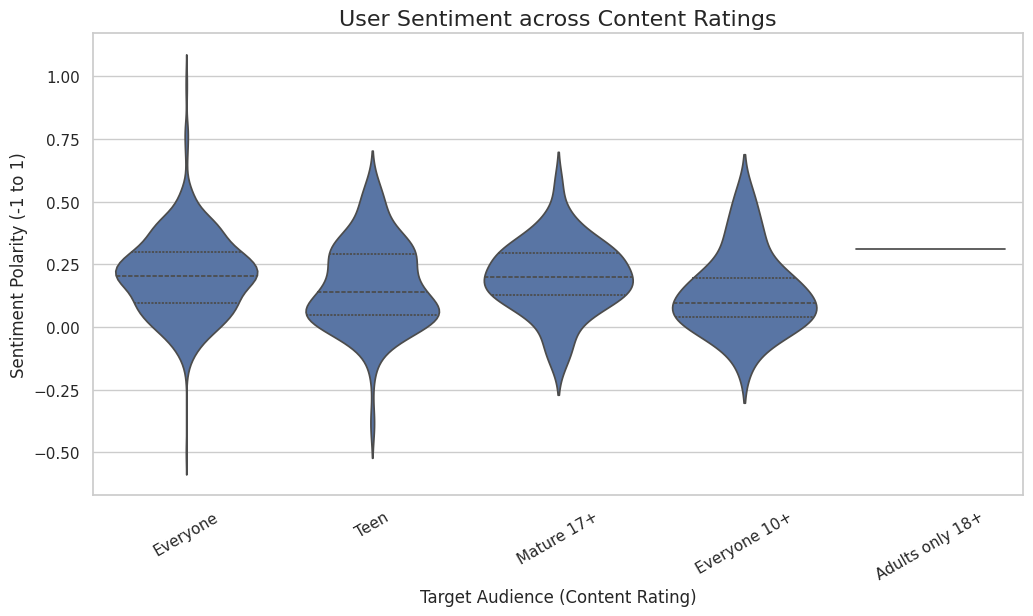

In [26]:
# Chart - 6 visualization code
sns.violinplot(x='Content Rating', y='Sentiment_Polarity', data=merged_df, inner="quartile")
plt.title('User Sentiment across Content Ratings', fontsize=16)
plt.xlabel('Target Audience (Content Rating)', fontsize=12)
plt.ylabel('Sentiment Polarity (-1 to 1)', fontsize=12)
plt.xticks(rotation=30)
plt.show()

##### 1. Why did you pick the specific chart?Most content ratings show a positive sentiment peak (above 0), but "Teen" and "Everyone" rated apps show more "Negative" outliers (tailing towards -1).

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 7

In [27]:
# Chart - 7 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 8

In [28]:
# Chart - 8 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 9

In [29]:
# Chart - 9 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 10

In [30]:
# Chart - 10 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 11

In [31]:
# Chart - 11 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 12

In [32]:
# Chart - 12 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 13

In [33]:
# Chart - 13 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 14 - Correlation Heatmap

In [34]:
# Correlation Heatmap visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

#### Chart - 15 - Pair Plot

In [35]:
# Pair Plot visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

Answer Here.


# **Conclusion**


Finding 1: The Review-Install Relationship

Observation: Our scatter plot showed a strong positive correlation between the number of reviews and the number of installs.

Insight: This suggests that user feedback acts as "Social Proof." Apps with more reviews are perceived as more trustworthy, leading to a higher download rate.

Finding 2: Pricing Strategy

Observation: From the box plot, we saw that Paid apps have a higher median rating than Free apps.

Insight: While free apps have more volume, paid users are often more loyal and satisfied. However, the correlation heatmap showed that increasing the price does not necessarily increase the rating.

Finding 3: Sentiment & Quality

Observation: Most reviews are positive, but the sentiment violin plot showed significant negativity in the "Teen" category.

Insight: Developers targeting younger audiences need to be more proactive in addressing bugs or UI complaints, as this demographic is more vocal with negative feedback.

Suggestion

Focus on Category Niche: Instead of entering the crowded "Family" or "Game" categories, developers should look at "Education" or "Health," which show high ratings but lower competition.

Optimize App Size: Since there is a slight negative trend between very large app sizes and installs, keeping the app under 50MB is ideal for global accessibility.

Engagement over Price: Focus on getting the first 1,000 reviews quickly (even via rewards or prompts), as this is the primary driver for moving into the "1M+ Installs" bracket.

Write the conclusion here.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***